<a href="https://colab.research.google.com/github/enriquefroes/previsao-brasileirao-2026/blob/main/notebooks/01_forca_dos_times.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE = '/content/drive/MyDrive/analise_previsao_brasileirao'
except ImportError:
    BASE = './analise_previsao_brasileirao'

DADOS, GRAF, TAB = (os.path.join(BASE, p) for p in ['dados', 'graficos', 'tabelas'])
for p in (GRAF, TAB):
    os.makedirs(p, exist_ok=True)

def salvar(nome):
    plt.tight_layout()
    plt.savefig(os.path.join(GRAF, nome), dpi=150, bbox_inches='tight')
    plt.show()
    print('Salvo em', os.path.join(GRAF, nome))

def exige(arquivo, notebook):
    if not os.path.exists(os.path.join(DADOS, arquivo)):
        raise FileNotFoundError(f'Rode primeiro o notebook {notebook}')

from sklearn.linear_model import PoissonRegressor
exige('partidas_realizadas.csv', '00_dados')

MEIA_VIDA = 180
ALPHA = 0.002
DATA_REFERENCIA = pd.Timestamp('2026-10-04')

p = pd.read_csv(os.path.join(DADOS, 'partidas_realizadas.csv'), parse_dates=['data'])
times = sorted(set(p['mandante']) | set(p['visitante']))
idx = {t: i for i, t in enumerate(times)}
n = len(times)

Mounted at /content/drive


In [2]:
X, y, w = [], [], []
for _, g in p.iterrows():
    peso = 0.5 ** ((DATA_REFERENCIA - g['data']).days / MEIA_VIDA)
    for atk, dfn, gols, casa in [(g['mandante'], g['visitante'], g['gols_mandante'], 1), (g['visitante'], g['mandante'], g['gols_visitante'], 0)]:
        v = np.zeros(2 * n + 1)
        v[0] = casa; v[1 + idx[atk]] = 1; v[1 + n + idx[dfn]] = 1
        X.append(v); y.append(gols); w.append(peso)
modelo = PoissonRegressor(alpha=ALPHA, max_iter=1000).fit(np.array(X), np.array(y), sample_weight=np.array(w))

forca = pd.DataFrame({'ataque': np.exp(modelo.coef_[1:n + 1]), 'defesa': np.exp(modelo.coef_[n + 1:])}, index=times)
forca['forca'] = forca['ataque'] / forca['defesa']
forca.index.name = 'time'
forca.sort_values('forca', ascending=False).round(3).to_csv(os.path.join(DADOS, 'forca_times.csv'))
pd.Series({'intercepto': modelo.intercept_, 'mando': modelo.coef_[0]}).to_csv(os.path.join(DADOS, 'parametros_modelo.csv'))
print(f'Vantagem de jogar em casa: {np.exp(modelo.coef_[0]):.2f}x mais gols')
forca.sort_values('forca', ascending=False).round(2)

Vantagem de jogar em casa: 1.31x mais gols


,ataque,defesa,forca
time,,,
Flamengo,1.46,0.65,2.26
Palmeiras,1.20,0.58,2.08
Athletico-PR,1.20,0.91,1.31
Fluminense,1.22,1.00,1.21
Atlético-MG,1.00,0.85,1.17
Cruzeiro,1.19,1.02,1.16
Bahia,1.15,0.99,1.16
Santos,1.18,1.08,1.09
Bragantino,0.89,0.87,1.03


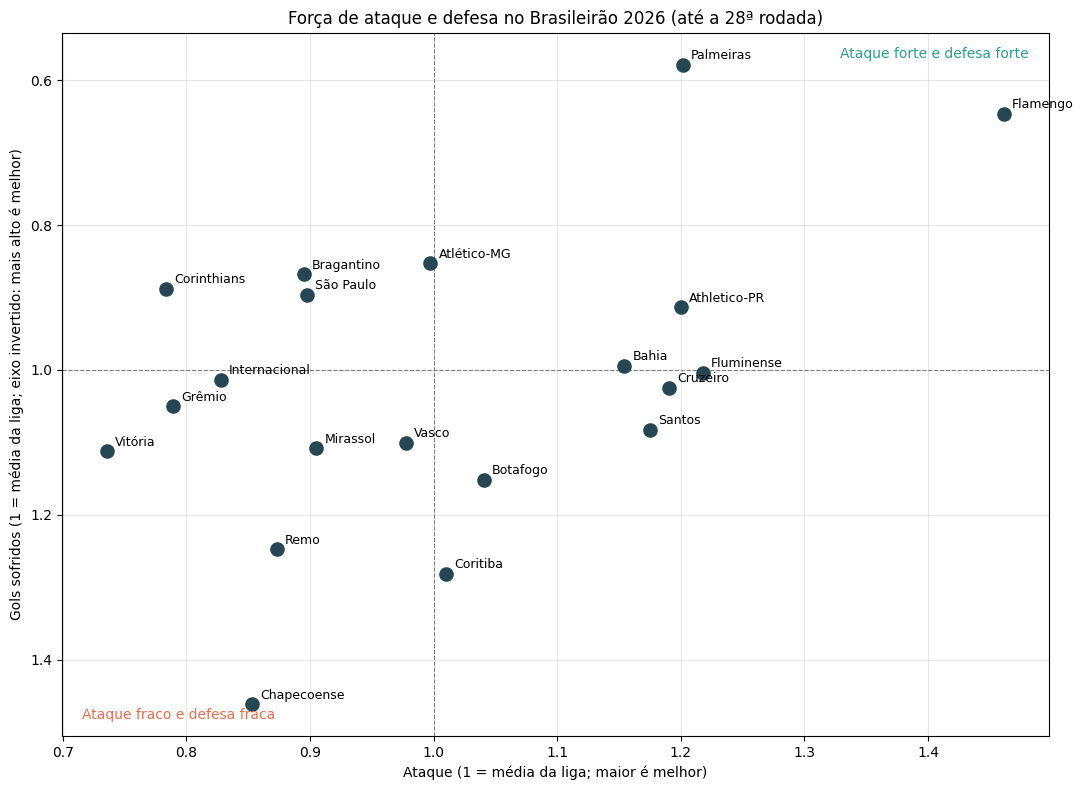

Salvo em /content/drive/MyDrive/analise_previsao_brasileirao/graficos/01a_ataque_x_defesa.png


In [3]:
fig, ax = plt.subplots(figsize=(11, 8))
ax.scatter(forca['ataque'], forca['defesa'], s=90, color='#264653', zorder=3)
for t, x in forca.iterrows():
    ax.annotate(t, (x['ataque'], x['defesa']), xytext=(6, 4), textcoords='offset points', fontsize=9)
ax.axvline(1, color='gray', lw=0.8, ls='--'); ax.axhline(1, color='gray', lw=0.8, ls='--')
ax.invert_yaxis()
ax.text(0.98, 0.98, 'Ataque forte e defesa forte', transform=ax.transAxes, ha='right', va='top', color='#2a9d8f')
ax.text(0.02, 0.02, 'Ataque fraco e defesa fraca', transform=ax.transAxes, ha='left', va='bottom', color='#e76f51')
ax.set_xlabel('Ataque (1 = média da liga; maior é melhor)')
ax.set_ylabel('Gols sofridos (1 = média da liga; eixo invertido: mais alto é melhor)')
ax.set_title('Força de ataque e defesa no Brasileirão 2026 (até a 28ª rodada)', fontsize=12)
ax.grid(alpha=0.3)
salvar('01a_ataque_x_defesa.png')